In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns
from scipy.stats import kurtosis
from scipy.stats import skew

In [285]:
# Step 1: Load the datasets
df_class_0 = pd.read_csv("dataset/graycomatrix_image_analysis_class_0.csv")
df_class_1 = pd.read_csv("dataset/graycomatrix_image_analysis_class_1.csv")


# Step 2: Add class labels to each dataset
df_class_0['target'] = 0  # Label for class 0
df_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined = pd.concat([df_class_0, df_class_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined = df_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [286]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        100 non-null    object 
 1   GLCM_Contrast     100 non-null    float64
 2   GLCM_Correlation  100 non-null    float64
 3   GLCM_Energy       100 non-null    float64
 4   GLCM_Homogeneity  100 non-null    float64
 5   LBP_0             100 non-null    float64
 6   LBP_1             100 non-null    float64
 7   LBP_2             100 non-null    float64
 8   LBP_3             100 non-null    float64
 9   LBP_4             100 non-null    float64
 10  LBP_5             100 non-null    float64
 11  LBP_6             100 non-null    float64
 12  LBP_7             100 non-null    float64
 13  LBP_8             100 non-null    float64
 14  LBP_9             100 non-null    float64
 15  LBP_10            100 non-null    float64
 16  LBP_11            100 non-null    float64
 17

## Random Forest:

In [346]:
# Step 4: Separate features (X) and target (y)
X = df_combined.drop(columns=['target', 'Unnamed: 0'])  # Features
y = df_combined['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=142)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [347]:
# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20

ROC-AUC Score: 0.8200000000000001


[[9 1]
 [2 8]]


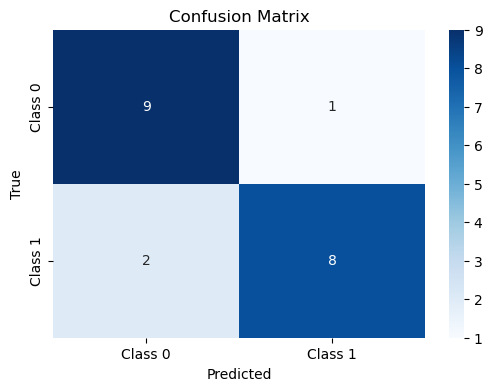

In [348]:
# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [345]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

             Feature  Importance
3   GLCM_Homogeneity    0.140742
2        GLCM_Energy    0.131450
28            LBP_24    0.128284
0      GLCM_Contrast    0.083661
23            LBP_19    0.051710
1   GLCM_Correlation    0.036529
15            LBP_11    0.033490
20            LBP_16    0.032792
19            LBP_15    0.028007
25            LBP_21    0.026299
29            LBP_25    0.026155
16            LBP_12    0.024842
13             LBP_9    0.022930
5              LBP_1    0.021936
6              LBP_2    0.021865
10             LBP_6    0.020055
18            LBP_14    0.018421
4              LBP_0    0.016400
14            LBP_10    0.015231
27            LBP_23    0.014753
11             LBP_7    0.012797
21            LBP_17    0.012612
12             LBP_8    0.011568
22            LBP_18    0.011130
26            LBP_22    0.010447
8              LBP_4    0.010379
9              LBP_5    0.009454
17            LBP_13    0.008941
24            LBP_20    0.008872
7         

In [291]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy: ", scores.mean())

Cross-Validation Accuracy:  0.8300000000000001


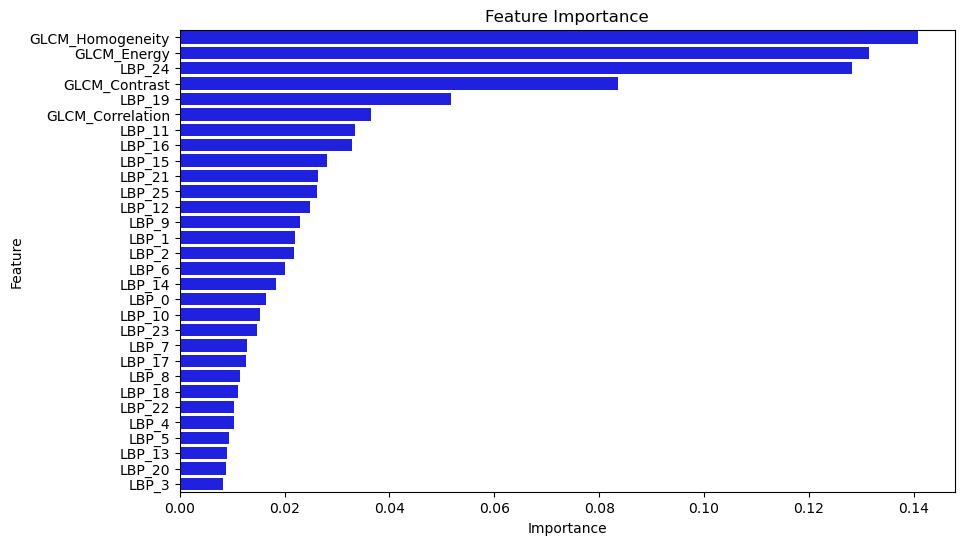

In [292]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [293]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=123), param_grid=param_grid, cv=5, scoring="accuracy", verbose=2)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

# Train model with the best parameters
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; tota

[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, min_

[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_s

[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2

[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_s

...

[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=No

[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf

[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf

[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samp

[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf

In [297]:
# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42, bootstrap=False, max_depth=None, min_samples_leaf=2,
                           min_samples_split=10, n_estimators=200)

# Train the model
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20

Confusion Matrix:
[[9 1]
 [2 8]]


In [298]:
from sklearn.feature_selection import SelectKBest, chi2

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42, bootstrap=False, max_depth=None, min_samples_leaf=1,
                           min_samples_split=2, n_estimators=500)
# Apply SelectKBest
selector = SelectKBest(score_func=chi2, k='all')  # k="all" to get scores for all features
#selector.fit(X_train, y_train)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)


rf.fit(X_train_selected, y_train)
# Get the scores of the selected features
feature_scores = selector.scores_

# Get the names of the features
feature_names = X_train.columns

# Create a DataFrame with feature names and their corresponding scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_scores
})

# Sort the features by score
feature_importance_df = feature_importance_df.sort_values(by='Score', ascending=False)

# Display the selected features with their scores
print(feature_importance_df)

# Predict on the test set
y_pred = rf.predict(X_test_selected)
y_pred_prob = rf.predict_proba(X_test_selected)[:, 1]  # Probabilities for the positive class

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

scores = cross_val_score(rf, X, y, cv=10, scoring='accuracy')
print(f"Cross-Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

             Feature        Score
0      GLCM_Contrast  1962.915525
1   GLCM_Correlation     0.069696
28            LBP_24     0.038839
3   GLCM_Homogeneity     0.018845
23            LBP_19     0.011571
5              LBP_1     0.006564
29            LBP_25     0.005352
25            LBP_21     0.004416
27            LBP_23     0.004409
20            LBP_16     0.004255
15            LBP_11     0.003143
24            LBP_20     0.002245
17            LBP_13     0.001629
2        GLCM_Energy     0.001525
19            LBP_15     0.001330
18            LBP_14     0.001322
10             LBP_6     0.001043
4              LBP_0     0.001026
22            LBP_18     0.000942
14            LBP_10     0.000744
9              LBP_5     0.000725
21            LBP_17     0.000595
8              LBP_4     0.000354
12             LBP_8     0.000303
16            LBP_12     0.000227
7              LBP_3     0.000129
13             LBP_9     0.000085
6              LBP_2     0.000047
26            

## Support Vector Machine Classificator:

In [299]:
# Split the data (assuming 'X' as features and 'y' as target variable)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [300]:
# Feature Selection with SelectKBest (using mutual information classification score)
selector = SelectKBest(score_func=mutual_info_classif, k='all')  # You can change 'k' to select top k features
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Initialize the SVM Classifier
svm_model = SVC(kernel='linear', random_state=42, probability=True)  # You can change kernel as needed ('linear', 'rbf', etc.)

# Train the SVM model
svm_model.fit(X_train_selected, y_train)

# Predictions and Evaluation
y_pred = svm_model.predict(X_test_selected)
y_pred_prob = svm_model.predict_proba(X_test_selected)[:, 1]

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.73      0.67      0.70        12

    accuracy                           0.65        20
   macro avg       0.64      0.65      0.64        20
weighted avg       0.66      0.65      0.65        20

Confusion Matrix:
[[5 3]
 [4 8]]


In [301]:
# ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# Cross-Validation
cross_val_accuracy = cross_val_score(svm_model, X_train_selected, y_train, cv=5)
print(f"Cross-Validation Accuracy: {np.mean(cross_val_accuracy):.4f} ± {np.std(cross_val_accuracy):.4f}")


ROC AUC Score: 0.75
Cross-Validation Accuracy: 0.7000 ± 0.1000


In [302]:
# Feature Selection with SelectKBest (using mutual information classification score)
selector = SelectKBest(score_func=mutual_info_classif, k=3)  # You can change 'k' to select top k features and 'all'
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Create SVC model
svc = SVC(random_state=42)

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 1, 10],
    'class_weight': [None, 'balanced']
}

svc=SVC()

# Set up Grid Search
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2)

# Fit Grid Search
grid_search.fit(X_train_selected, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_selected, y_test)
print("Test Accuracy:", test_accuracy)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END C=0.1, class_weight=None, gamma=scale, kernel=linear; total time=   0.0s
[CV] END C=0.1, class_weight=None, gamma=scale, kernel=linear; total time=   0.0s
[CV] END C=0.1, class_weight=None, gamma=scale, kernel=linear; total time=   0.0s
[CV] END C=0.1, class_weight=None, gamma=scale, kernel=linear; total time=   0.0s
[CV] END C=0.1, class_weight=None, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..C=0.1, class_weight=None, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..C=0.1, class_weight=None, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..C=0.1, class_weight=None, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..C=0.1, class_weight=None, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..C=0.1, class_weight=None, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END C=0.1, class_weight=None, gamma=auto, kernel=linear; total time=   0.0s
[CV] END C=0.1, class_weight=None, gamma=a

[CV] END C=10, class_weight=balanced, gamma=auto, kernel=linear; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END C=10, class_weight=balanced, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END .C=10, class_weight=balanced, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .C=10,

In [305]:
# Initialize the SVM Classifier
svm_model = SVC(kernel='rbf', random_state=42, probability=True,
               class_weight= 'balanced', gamma=0.1, C=1)  

# Train the SVM model
svm_model.fit(X_train_selected, y_train)

# Predictions and Evaluation
y_pred = svm_model.predict(X_test_selected)
y_pred_prob = svm_model.predict_proba(X_test_selected)[:, 1]

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.73      0.67      0.70        12

    accuracy                           0.65        20
   macro avg       0.64      0.65      0.64        20
weighted avg       0.66      0.65      0.65        20

Confusion Matrix:
[[5 3]
 [4 8]]


## XGBoost:

In [276]:
from xgboost import XGBClassifier

In [306]:
# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Fit the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]  # For ROC/AUC

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       0.83      0.83      0.83        12

    accuracy                           0.80        20
   macro avg       0.79      0.79      0.79        20
weighted avg       0.80      0.80      0.80        20


Confusion Matrix:
[[ 6  2]
 [ 2 10]]

ROC AUC Score: 0.7917


In [337]:
# Feature Selection with SelectKBest (using mutual information classification score)
selector = SelectKBest(score_func=mutual_info_classif, k=4)  # You can change 'k' to select top k features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, max_depth=None)

# Fit the model
xgb_model.fit(X_train_selected, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test_selected)
y_pred_prob = xgb_model.predict_proba(X_test_selected)[:, 1]  # For ROC/AUC

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       0.83      0.83      0.83        12

    accuracy                           0.80        20
   macro avg       0.79      0.79      0.79        20
weighted avg       0.80      0.80      0.80        20


Confusion Matrix:
[[ 6  2]
 [ 2 10]]

ROC AUC Score: 0.8125


In [308]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


# Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',  # Change to 'recall' or 'roc_auc' if desired
                           cv=5,
                           verbose=1,
                           n_jobs=-1)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best parameters and model evaluation
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Evaluate the optimized model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nOptimized ROC AUC Score: {roc_auc:.4f}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.6}

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71         8
           1       0.82      0.75      0.78        12

    accuracy                           0.75        20
   macro avg       0.74      0.75      0.74        20
weighted avg       0.76      0.75      0.75        20


Confusion Matrix:
[[6 2]
 [3 9]]

Optimized ROC AUC Score: 0.7917


In [323]:
# Feature Selection with SelectKBest (using mutual information classification score)
selector = SelectKBest(score_func=mutual_info_classif, k=1)  # You can change 'k' to select top k features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)


# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                         max_depth=3, n_estimator=200, subsample=0.6,
                         learning_rate=0.01, colsample_bytree=0.8)

# Fit the model
xgb_model.fit(X_train_selected, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test_selected)
y_pred_prob = xgb_model.predict_proba(X_test_selected)[:, 1]  # For ROC/AUC

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           1       0.89      0.67      0.76        12

    accuracy                           0.75        20
   macro avg       0.76      0.77      0.75        20
weighted avg       0.79      0.75      0.75        20


Confusion Matrix:
[[7 1]
 [4 8]]

ROC AUC Score: 0.8490


/Users/solozobovavaleria/anaconda3/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning: [21:16:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)
